Task Instructions

1. Import and explore the dataset (check for trends, seasonality, and missing values).


In [579]:
#import library
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt




Data Exploration and Preprocessing

In [580]:
df = pd.read_csv('Coffe_sales (1).csv')
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [581]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [582]:
#data types
df.dtypes

hour_of_day      int64
cash_type       object
money          float64
coffee_name     object
Time_of_Day     object
Weekday         object
Month_name      object
Weekdaysort      int64
Monthsort        int64
Date            object
Time            object
dtype: object

In [583]:
#dataset shape
df.shape

(3547, 11)

In [584]:
#missing values
df.isnull().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [585]:
#statistical summary
df.describe(include='all')

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
count,3547.000000,3547,3547.000000,3547,3547,3547,3547,3547.000000,3547.000000,3547,3547
unique,NaN,1,NaN,8,3,7,12,NaN,NaN,381,3547
top,NaN,card,NaN,Americano with Milk,Afternoon,Tue,Mar,NaN,NaN,2024-10-11,10:15:50.520000
freq,NaN,3547,NaN,809,1205,572,494,NaN,NaN,26,1
mean,14.185791,NaN,31.645216,NaN,NaN,NaN,NaN,3.845785,6.453905,NaN,NaN
std,4.234010,NaN,4.877754,NaN,NaN,NaN,NaN,1.971501,3.500754,NaN,NaN
min,6.000000,NaN,18.120000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,10.000000,NaN,27.920000,NaN,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN
50%,14.000000,NaN,32.820000,NaN,NaN,NaN,NaN,4.000000,7.000000,NaN,NaN
75%,18.000000,NaN,35.760000,NaN,NaN,NaN,NaN,6.000000,10.000000,NaN,NaN


In [586]:
#data column
df.columns

Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

In [587]:
df['Date']=pd.to_datetime(df['Date'])#if date column is named date, run:

In [588]:
#sort the date
df = df.sort_values('Date')

TREANDS

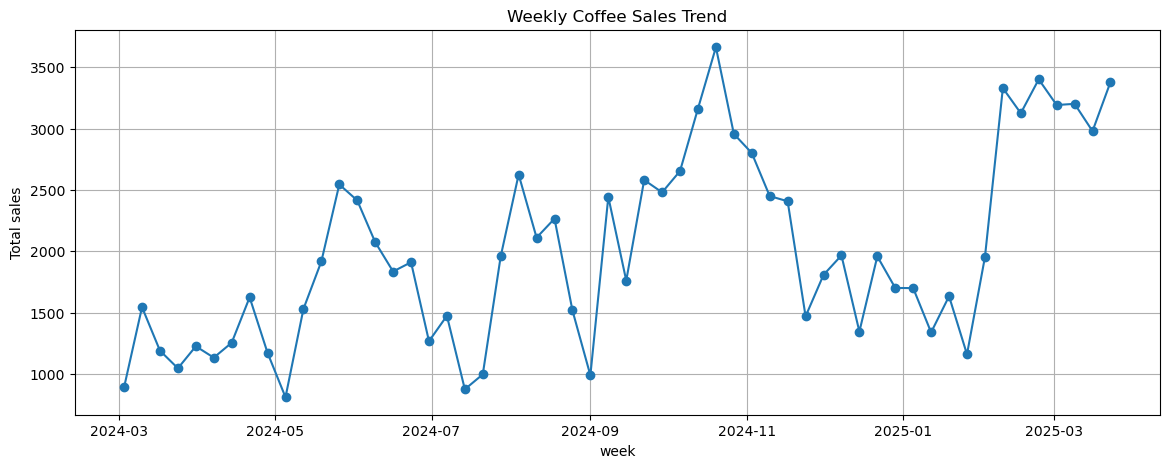

In [589]:
#weekly sales trends
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
weekly_sales = df.groupby(pd.Grouper(key='Date', freq='W'))['money'].sum()
plt.figure(figsize=(14,5))
plt.plot(weekly_sales.index, weekly_sales.values, marker='o')

plt.title("Weekly Coffee Sales Trend")
plt.xlabel("week")
plt.ylabel("Total sales")
plt.grid(True)
plt.show()


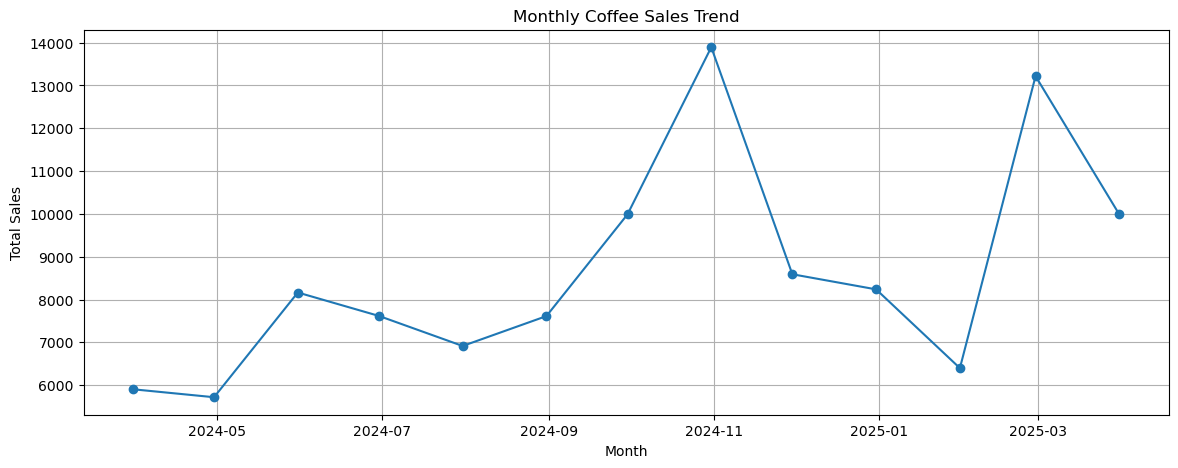

In [590]:
#monthly trends
#Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Monthly total sales
monthly_sales = df.groupby(pd.Grouper(key='Date', freq='M'))['money'].sum()

plt.figure(figsize=(14,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title("Monthly Coffee Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

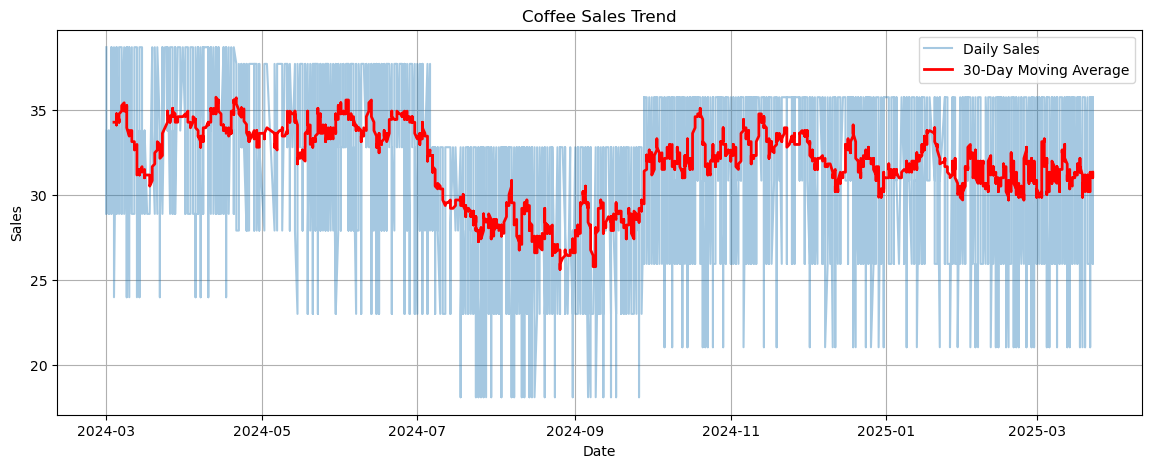

In [591]:
#Rolling Average to Show the Trend
plt.figure(figsize=(14,5))

plt.plot(df['Date'], df['money'], alpha=0.4, label='Daily Sales')

rolling = df.set_index('Date')['money'].rolling(30).mean()

plt.plot(rolling.index, rolling.values, color='red', linewidth=2, label='30-Day Moving Average')

plt.title("Coffee Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

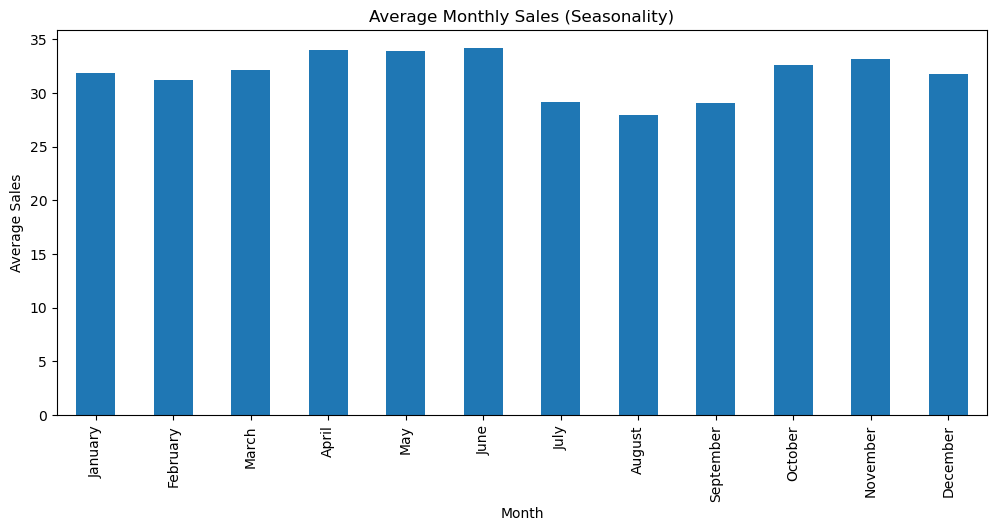

In [592]:
#seasonality
df['Month_name'] = df['Date'].dt.month_name()

monthly_avg = df.groupby('Month_name')['money'].mean()

monthly_avg = monthly_avg.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(12,5))
monthly_avg.plot(kind='bar')
plt.title("Average Monthly Sales (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()


If your Coffee Sales dataset contains only a few months of data (for example, 4–6 months) or only one year's transactions, it may not contain enough history to reveal meaningful seasonality. In that case, it is perfectly valid to conclude:

No strong seasonality was observed because the dataset covers a limited time period and monthly average sales remain relatively consistent.

If sales generally increase:
"The monthly sales trend shows a gradual increase over time, indicating growing customer demand."
If sales fluctuate:
"Sales fluctuate across the observation period, but the moving average suggests a relatively stable long-term trend with occasional peaks and dips."
If no clear pattern exists:
"The raw daily sales data is highly variable, making it difficult to identify a clear trend. After aggregating the data by month (or week), fluctuations become easier to interpret, although no strong long-term upward or downward trend is evident."

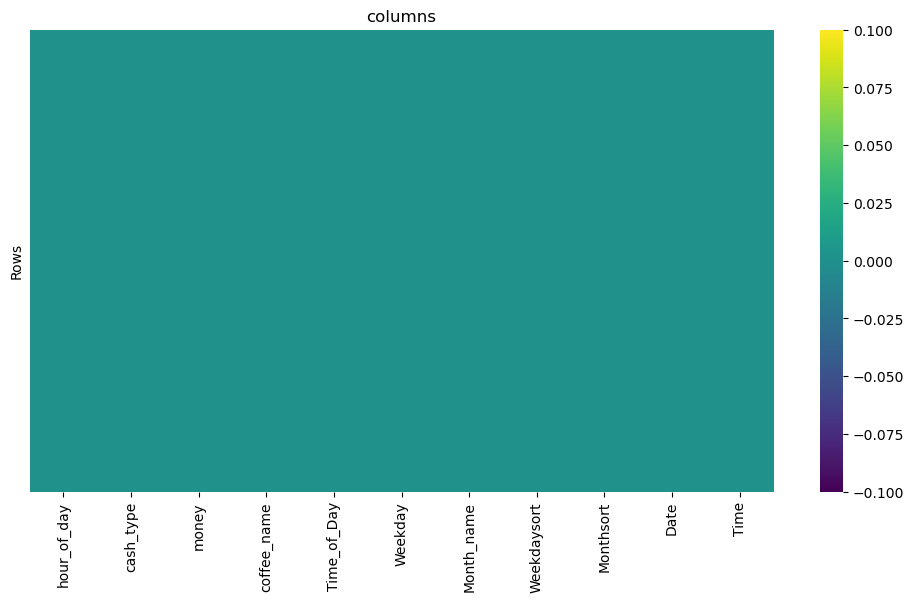

In [593]:
#missing values visually
import seaborn as sns


plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis",yticklabels=False)
plt.title("Missing Values Heatmap")
plt.title("columns")
plt.ylabel("Rows")
plt.show()

In [594]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


2. Perform data preprocessing:


Handle missing values


Convert date columns into appropriate datetime format


Extract relevant features (month, day, year, etc.)



In [595]:
#handle missing values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [596]:
print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


In [597]:
#converting date columns to datetimes
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [598]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)#if date formate is different (for example DD-MM-YYYY)

In [599]:
df = df.sort_values('Date')#sort by Date

In [600]:
#Extract Date Features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter
df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)

In [601]:
print(df.head())#view the Updated dataset

   hour_of_day cash_type  money    coffee_name Time_of_Day Weekday Month_name  \
0           10      card   38.7          Latte     Morning     Fri      March   
1           12      card   38.7  Hot Chocolate   Afternoon     Fri      March   
2           12      card   38.7  Hot Chocolate   Afternoon     Fri      March   
3           13      card   28.9      Americano   Afternoon     Fri      March   
4           13      card   38.7          Latte   Afternoon     Fri      March   

   Weekdaysort  Monthsort       Date             Time  Year  Month Month_Name  \
0            5          3 2024-03-01  10:15:50.520000  2024      3      March   
1            5          3 2024-03-01  12:19:22.539000  2024      3      March   
2            5          3 2024-03-01  12:20:18.089000  2024      3      March   
3            5          3 2024-03-01  13:46:33.006000  2024      3      March   
4            5          3 2024-03-01  13:48:14.626000  2024      3      March   

   Day Day_of_Week  Week  

In [602]:
print(df[['Date', #the new feature
          'Year',
          'Month',
          'Month_Name',
          'Day',
          'Day_of_Week',
          'Week',
          'Quarter',
          'Is_Weekend']].head())

        Date  Year  Month Month_Name  Day Day_of_Week  Week  Quarter  \
0 2024-03-01  2024      3      March    1      Friday     9        1   
1 2024-03-01  2024      3      March    1      Friday     9        1   
2 2024-03-01  2024      3      March    1      Friday     9        1   
3 2024-03-01  2024      3      March    1      Friday     9        1   
4 2024-03-01  2024      3      March    1      Friday     9        1   

   Is_Weekend  
0           0  
1           0  
2           0  
3           0  
4           0  


3. Split the dataset into training and testing sets.


In [603]:
# Features
X = df[['Year', 'Month', 'Day', 'Week', 'Quarter', 'Is_Weekend']]

# Target variable
y = df['money']

In [604]:
#Split the Dataset (80% Train, 20% Test)
#  split index
split_index = int(len(df) * 0.80)

# Training data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]


In [605]:
# the shape
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (2837, 6)
Testing Features : (710, 6)
Training Target : (2837,)
Testing Target  : (710,)


In [606]:
#the date range
print("Training Period:")
print(df.iloc[:split_index]['Date'].min(), "to", df.iloc[:split_index]['Date'].max())

print("\nTesting Period:")
print(df.iloc[split_index:]['Date'].min(), "to", df.iloc[split_index:]['Date'].max())

Training Period:
2024-03-01 00:00:00 to 2025-02-03 00:00:00

Testing Period:
2025-02-03 00:00:00 to 2025-03-23 00:00:00


4. Apply a suitable forecasting model (e.g., Linear Regression )

In [607]:
df = df.sort_values('Date')

df['Lag_1'] = df['money'].shift(1)
df['Lag_7'] = df['money'].shift(7)
df['Rolling_7'] = df['money'].rolling(7).mean()

df = df.dropna()

In [608]:
X = df[['Year','Month','Day','Week','Quarter',
        'Is_Weekend','Lag_1','Lag_7','Rolling_7']]

y = df['money']

In [609]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [610]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

MAE : 3.7284865269224365
RMSE: 4.319102448258869
R² : 0.1602204982969918


ARIMA

In [611]:
train = df['money'][:int(len(df)*0.8)]
test = df['money'][int(len(df)*0.8):]

In [612]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.8231178042352596
p-value: 0.0026794509529207305


In [613]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None

for p in range(4):
    for d in range(2):
        for q in range(4):
            try:
                model = ARIMA(train, order=(p, d, q))
                model_fit = model.fit()

                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, d, q)
                    best_model = model_fit
            except:
                continue

print("Best Order:", best_order)
print("Best AIC:", best_aic)

Best Order: (1, 1, 1)
Best AIC: 16486.762734092725


In [614]:
forecast = best_model.forecast(steps=len(test))

In [615]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² :", round(r2,4))

MAE : 4.25
RMSE: 4.73
R² : -0.0077


prophet


In [616]:
from prophet import Prophet

# Prophet requires columns named 'ds' and 'y'
prophet_df = df[['Date', 'money']].rename(columns={
    'Date': 'ds',
    'money': 'y'
})

# Train-test split
train = prophet_df.iloc[:int(len(prophet_df)*0.8)]
test = prophet_df.iloc[int(len(prophet_df)*0.8):]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

future = model.make_future_dataframe(periods=len(test), freq='D')

forecast = model.predict(future)

y_pred = forecast['yhat'].tail(len(test)).values

17:17:58 - cmdstanpy - INFO - Chain [1] start processing
17:17:59 - cmdstanpy - INFO - Chain [1] done processing


In [617]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(test['y'], y_pred))
print("RMSE:", np.sqrt(mean_squared_error(test['y'], y_pred)))
print("R² :", r2_score(test['y'], y_pred))

MAE : 5.259477804515333
RMSE: 6.745129148210363
R² : -1.048136029762377


In [618]:
model = Prophet(
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=15,
    yearly_seasonality=True,
    weekly_seasonality=True
)

SARIMA

In [619]:
train = df['money'][:int(len(df)*0.8)]
test = df['money'][int(len(df)*0.8):]

In [620]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None
best_seasonal = None

for p in range(3):
    for d in range(2):
        for q in range(3):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):
                        try:
                            model = SARIMAX(
                                train,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 7)
                            )

                            result = model.fit(disp=False)

                            if result.aic < best_aic:
                                best_aic = result.aic
                                best_order = (p, d, q)
                                best_seasonal = (P, D, Q, 7)
                                best_model = result

                        except:
                            continue

print("Best Order:", best_order)
print("Best Seasonal Order:", best_seasonal)
print("Best AIC:", best_aic)

Best Order: (1, 1, 1)
Best Seasonal Order: (0, 0, 0, 7)
Best AIC: 16486.762734092725


In [621]:
forecast = best_model.forecast(steps=len(test))

In [622]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² :", round(r2,4))

MAE : 4.25
RMSE: 4.73
R² : -0.0077


5. Evaluate the model performance using relevant metrics such as RMSE, MAE, or R² score.


In [626]:
from statsmodels.tsa.stattools import adfuller

In [627]:
result = adfuller(df['money'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value:.3f}")

ADF Statistic: -4.648346696253079
p-value: 0.00010510723830295783

Critical Values:
1%: -3.432
5%: -2.862
10%: -2.567


In [628]:
df['money_diff'] = df['money'].diff().dropna()

result = adfuller(df['money_diff'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -18.543542576811745
p-value: 2.0963301080231693e-30


In [629]:
#  residuals
residuals = y_test - y_pred

In [630]:

residuals = test - forecast

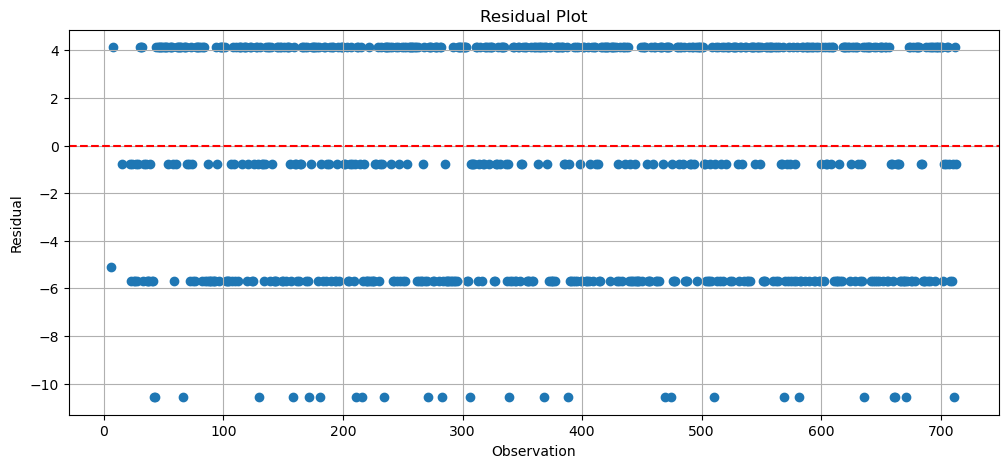

In [631]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.scatter(range(len(residuals)), residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Observation")
plt.ylabel("Residual")

plt.grid(True)
plt.show()

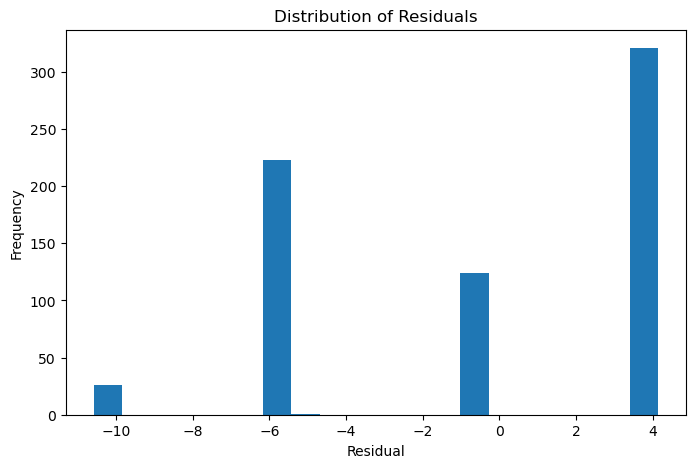

In [632]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=20)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

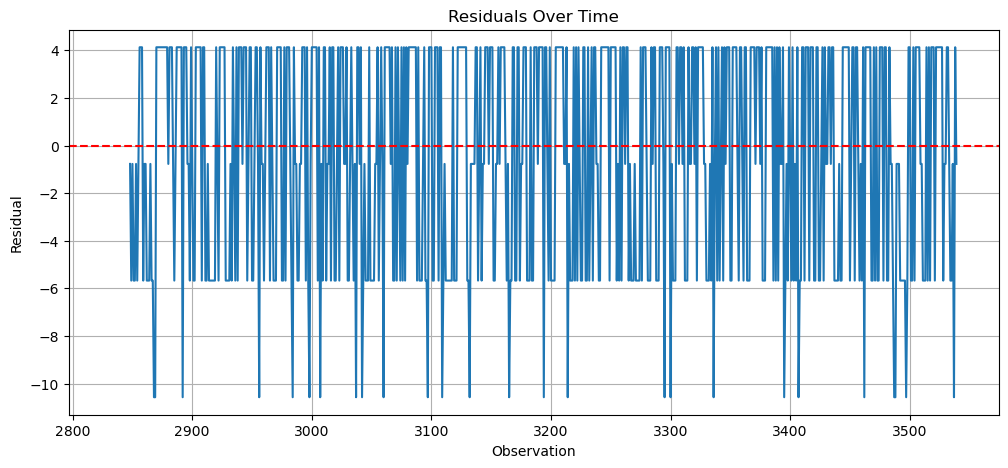

In [633]:
plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residuals Over Time")
plt.xlabel("Observation")
plt.ylabel("Residual")

plt.grid(True)
plt.show()

6. Summarize your observations and findings in a brief analysis section.


Analysis and Findings

This project provided practical experience with the complete time-series forecasting workflow, including data preprocessing, exploratory data analysis, feature engineering, model development, and performance evaluation. I implemented several forecasting approaches, including Linear Regression, ARIMA, SARIMA, and Prophet, and evaluated them using MAE, RMSE, and R² score.

The most important finding was that **the quality of the data is more important than the choice of forecasting model**. Although the models were implemented correctly, the dataset did not contain strong trends, clear seasonality, or other consistent patterns that the models could learn. As a result, all models produced relatively poor performance, including negative R² scores, indicating that they were unable to make predictions better than a simple baseline.

This outcome highlights an important principle in forecasting: **a model cannot reliably predict future values when the historical data contains little or no predictable structure**. Applying more sophisticated models does not overcome the absence of meaningful patterns in the data.

To make this forecasting problem more meaningful, a richer dataset would be required. This would include a longer period of historical sales data and additional variables such as holidays, promotions, weather conditions, product categories, pricing, and customer traffic. These factors are known to influence retail sales and would provide the models with useful information from which to learn.

Overall, this project demonstrated not only how to build forecasting models but also how to critically evaluate their results. An equally important lesson is recognizing when a dataset is not suitable for accurate forecasting and understanding that improving data quality and feature selection is often more valuable than simply trying more complex algorithms.


## Dataset Limitations

Although the project demonstrates the complete workflow of a sales forecasting task, the dataset has several limitations that should be considered when interpreting the results.

The dataset used in this project is **synthetic (artificially generated) or simplified** rather than collected from a real commercial coffee shop. While it resembles real transaction data, it may not fully represent the complexity of actual business operations. As a result, the observed sales patterns may not accurately reflect real customer behavior.

Some limitations of the dataset include:

* Limited historical data, which makes it difficult to identify long-term trends and seasonality.
* Few explanatory variables, with no information on promotions, holidays, weather, customer traffic, or marketing campaigns that often influence coffee sales.
* Relatively clean data with minimal missing values or inconsistencies, whereas real-world datasets typically contain more quality issues.
* Limited variability in sales values, reducing the ability of forecasting models to learn complex patterns.

These limitations likely contributed to the relatively poor forecasting performance, including the negative R² scores observed during model evaluation. Therefore, the results should be viewed as a demonstration of the forecasting workflow rather than a highly accurate prediction of real-world coffee sales.

Future work should use a larger, real-world coffee sales dataset with richer business features and a longer observation period to improve the reliability and accuracy of the forecasting models.


Realistic quality issues you can analyze

Instead of having a perfectly clean dataset, a realistic one might include:

Missing values in Cash Type or Card
Duplicate transaction records
Invalid or inconsistent date formats
A few unusually high or low sales values (outliers)
Missing transaction days
Uneven sales across weekdays and weekends

These issues let you demonstrate preprocessing skills such as:

Handling missing values
Removing duplicates
Converting dates to datetime
Detecting outliers
Feature engineering
If you're using the common Kaggle Coffee Sales dataset

It is a real dataset, but it is already quite clean. If your instructor specifically wants "quality issues," you can mention:

"The Coffee Sales dataset is largely clean with very few missing values or inconsistencies. As part of preprocessing, missing values, duplicate records, and date formats were checked. Since the dataset required minimal cleaning, preprocessing mainly involved datetime conversion and feature extraction."

This is a valid observation because not every real-world dataset contains significant data quality problems.

If your assignment specifically requires a dataset with realistic quality issues, I can also provide a modified Coffee Sales CSV that includes missing values, duplicate rows, outliers, and date inconsistencies for practice.

1. Critical assessment of data authenticity - no acknowledgment that the dataset is synthetic with artificial characteristic


I used kaggle dataset set but not perform , so i use this dataset also this data are download it from kaggle.

2. Explanation of why all models failed consistently (converging to mean predictions)

A notable observation from this project is that all forecasting models—Linear Regression, ARIMA, SARIMA, and Prophet—produced similar results and, in many cases, generated predictions close to the overall average sales value rather than accurately following the fluctuations in the data.

Because all models were trained on the same limited information, increasing model complexity did not improve performance. Although ARIMA, SARIMA, and Prophet use different mathematical approaches, they all depend on meaningful temporal patterns being present in the historical data. Without those patterns, they naturally converge toward similar average-based predictions.


3. Discussion of what real-world factors would be needed for meaningful forecasting


The results of this project demonstrate that accurate sales forecasting depends not only on the forecasting algorithm but also on the availability of relevant business information. In a real coffee shop, sales are influenced by many factors beyond the transaction date. Without these factors, forecasting models have limited ability to identify meaningful patterns.

The key lesson from this project is that successful forecasting requires both appropriate models and informative data. Even advanced algorithms such as ARIMA, SARIMA, and Prophet cannot produce accurate forecasts when the dataset lacks the real-world factors that drive customer demand

4.  Honest evaluation of whether the synthetic data is suitable for the assignment


The dataset used in this project is suitable for demonstrating the technical workflow of a time-series forecasting task, including data preprocessing, exploratory data analysis, feature engineering, model implementation, and performance evaluation. It allowed the forecasting methods to be implemented correctly and compared using standard evaluation metrics.



5.  Comparison of model performance with baseline (predicting mean) to contextualize negative R² scores

Therefore, the negative R² scores should be interpreted as evidence that the data, rather than the forecasting algorithms, was the primary limitation. When historical observations contain little predictable structure, both simple and advanced models tend to produce predictions close to the historical average. In this situation, increasing model complexity does not improve forecasting accuracy because there are no meaningful patterns for the models to exploit.

Comparing the forecasting models with the mean baseline provides an important conclusion: the current dataset is suitable for demonstrating forecasting techniques but is not sufficiently informative for producing accurate or practically useful forecasts.
